# CHAPTER 6: Testing for Stationarity 

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

np.random.seed(42)


sns.set_theme(
    context="talk",
    style="whitegrid",
    palette="colorblind",
    color_codes=True,
    rc={"figure.figsize":[12,8]}
)

In [24]:
#let's bring out clean dataset to our new notebook
import pandas as pd

df_final = pd.read_csv(
    "mxn_forecasting_clean.csv",
    index_col=0,
    parse_dates=True
)
df_final = df_final.dropna()
df_final.head()

,mxn_usd,oil_prices,usd_mxn_returns,oil_returns,vix,fed_funds_rate,industrial_activity,inflation_rate,banxico_rate,vix_returns
2008-01-23,10.893,87.65,-0.002933,-0.022450,29.020000,3.94,100.9807,3.704372,7.5,-0.066324
2008-01-24,10.862,89.98,-0.002850,0.026236,27.780001,3.94,100.9807,3.704372,7.5,-0.043669
2008-01-25,10.866,90.37,0.000368,0.004325,29.080000,3.94,100.9807,3.704372,7.5,0.045734
2008-01-28,10.863,90.99,-0.000276,0.006837,27.780001,3.94,100.9807,3.704372,7.5,-0.045734
2008-01-29,10.841,91.66,-0.002027,0.007336,27.320000,3.94,100.9807,3.704372,7.5,-0.016697


2. Define a function for running the ADN test. 

In [26]:
from statsmodels.tsa.stattools import adfuller

def adf_test(x):

    indices = [ "Test Statistic", "p-value", "# of Lags Used", "# of Observations Used"]

    test = adfuller(x, autolag="AIC")

    results = pd.Series(
        test[0:4],
        index=indices )

    for key, value in test[4].items():
        results[f"Critical Value ({key})"] = value

    return results

In [ ]:
    """
    Function for performing the Augmented Dickey-Fuller test for stationarity
    
    Null Hypothesis: time series is not stationary
    Alternate Hypothesis: time series is stationary

    Parameters
    ----------
    x : pd.Series / np.array
        The time series to be checked for stationarity
    
    Returns
    -------
    results: pd.DataFrame
        A DataFrame with the ADF test's results
    """

In [25]:
adf_test(df_final["usd_mxn_returns"])

Test Statistic           -1.434026e+01
p-value                   1.062978e-26
# of Lags Used            1.900000e+01
# of Observations Used    4.223000e+03
Critical Value (1%)      -3.431899e+00
Critical Value (5%)      -2.862225e+00
Critical Value (10%)     -2.567134e+00
dtype: float64

p-value < 0.001 then we reject the H0, so the series is stationary. and the -14.34 < -2.86 so the Test statistic is much more negative than the 5% creitical value. 

3. Define a function for running the KPSS test:

In [ ]:
 """
    Function for performing the Kwiatkowski-Phillips-Schmidt-Shin test for stationarity

    Null Hypothesis: time series is stationary
    Alternate Hypothesis: time series is not stationary

    Parameters
    ----------
    x: pd.Series / np.array
        The time series to be checked for stationarity
    h0_type: str{"c", "ct"}
        Indicates the null hypothesis of the KPSS test:
            * "c": The data is stationary around a constant(default)
            * "ct": The data is stationary around a trend
    
    Returns
    -------
    results: pd.DataFrame
        A DataFrame with the KPSS test's results
    """
    Note:
    Level Sationary: La serie es estacionaria alrededor de una cosntante. 
    Trend Sationary: La serie es estacionaria alrededor de una tendensia determinista. 
    
    
    

In [32]:
from statsmodels.tsa.stattools import kpss

def kpss_test(x, h0_type="c"):

    indices = [
        "Test Statistic",
        "p-value",
        "# of Lags"
    ]

    test = kpss(
        x,
        regression=h0_type
    )

    results = pd.Series(
        test[0:3],
        index=indices
    )

    for key, value in test[3].items():
        results[f"Critical Value ({key})"] = value

    return results

In [33]:
kpss_test(df_final["usd_mxn_returns"])

/var/folders/02/hyh46k810q3crfrg2kjcc3_w0000gn/T/ipykernel_11678/4001525561.py:11: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  test = kpss(


Test Statistic            0.062939
p-value                   0.100000
# of Lags                10.000000
Critical Value (10%)      0.347000
Critical Value (5%)       0.463000
Critical Value (2.5%)     0.574000
Critical Value (1%)       0.739000
dtype: float64

p-value: 0.10 > 0.05 then don't reject H0, and series is stationary. the test statistic < critical value(5%) the we dont reject the H0. 

4.Generate the ACF/PACF plots:

In [35]:
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)

import matplotlib.pyplot as plt

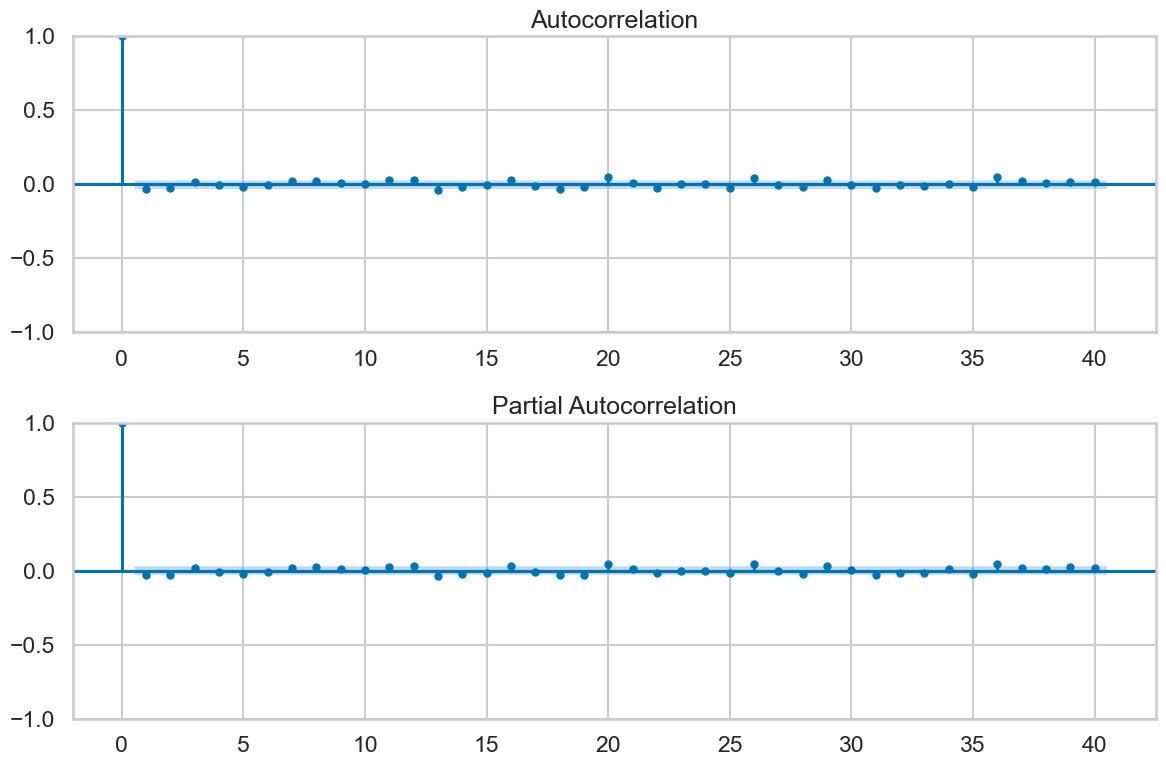

In [37]:
fig, ax = plt.subplots(2,1, figsize=(12,8))

plot_acf(
    df_final["usd_mxn_returns"],
    lags=40,
    ax=ax[0]
)

plot_pacf(
    df_final["usd_mxn_returns"],
    lags=40,
    ax=ax[1]
)

plt.tight_layout()
plt.show()

The ACF and PACF plots show only weak serial dependence, with autocorrelations close to zero at all lags. This suggests that past returns contain little information about future returns and that the series behaves approximately as a weakly dependent stationary process.

5. Carry out the ADF test using the arch library:

In [41]:
from arch.unitroot import ADF

In [43]:
from arch.unitroot import ADF

adf = ADF(
    df_final["usd_mxn_returns"].dropna()
)

print(adf.summary().as_text())

   Augmented Dickey-Fuller Results   
Test Statistic                -14.340
P-value                         0.000
Lags                               19
-------------------------------------

Trend: Constant
Critical Values: -3.43 (1%), -2.86 (5%), -2.57 (10%)
Null Hypothesis: The process contains a unit root.
Alternative Hypothesis: The process is weakly stationary.


p-value:0.000 <0.05 the dont reject H0(The process contains a unit root (the series is non-stationary). and Test Statistic < critical value 5%.